In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import anndata
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
from diptest import diptest
from binning import *

In [2]:
"""
We assume that the spot coordinates (avaiable with the datasets) are in um unit.
"""

'\nWe assume that the spot coordinates (avaiable with the datasets) are in um unit.\n'

### Merfish Ileu - xy

In [3]:

path = "/data/Ajita/Spatial/Datasets/Spatial_Deconvolution/_Image_Binned_datasets/MERFISH_ileum/ST/"

unbinned_st_path = path + "unbinned_ST/ST.h5ad"

binned_path = path + "ST_55_python.h5ad"

dataset =  "merfish_ileum"
celltype_col = "cell_type"
spot_diameter = 100 #55 # 550 -> 510 # 100->6, 9, etc.
coord1 = 0
coord2 = 1

combined_adata = binning(unbinned_st_path, spot_diameter, celltype_col, dataset, coord1, coord2)
print (combined_adata)

Number of spots in mask: 1
Number of spots in mask: 3
Number of spots in mask: 2
Number of spots in mask: 1
Number of spots in mask: 2
Number of spots in mask: 1
Number of spots in mask: 3
Number of spots in mask: 2
Number of spots in mask: 1
Number of spots in mask: 1
Number of spots in mask: 1
Number of spots in mask: 3
Number of spots in mask: 1
Number of spots in mask: 1
Number of spots in mask: 3
Number of spots in mask: 1
Number of spots in mask: 1
Number of spots in mask: 1
Number of spots in mask: 1
Number of spots in mask: 1
Number of spots in mask: 4
Number of spots in mask: 1
Number of spots in mask: 1
Number of spots in mask: 1
Number of spots in mask: 1
Number of spots in mask: 1
Number of spots in mask: 1
Number of spots in mask: 1
Number of spots in mask: 1
Number of spots in mask: 4
Number of spots in mask: 2
Number of spots in mask: 3
Number of spots in mask: 2
Number of spots in mask: 1
Number of spots in mask: 2
Number of spots in mask: 3
Number of spots in mask: 5
N

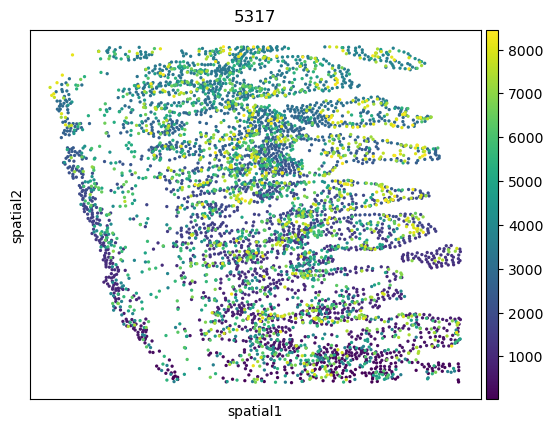

In [4]:
st_adata = sc.read_h5ad(unbinned_st_path)
st_adata.obs["umi_count"] = st_adata.X.sum(axis = 1)
sc.pl.embedding(st_adata, basis = "spatial", color = "umi_count", title = st_adata.shape)

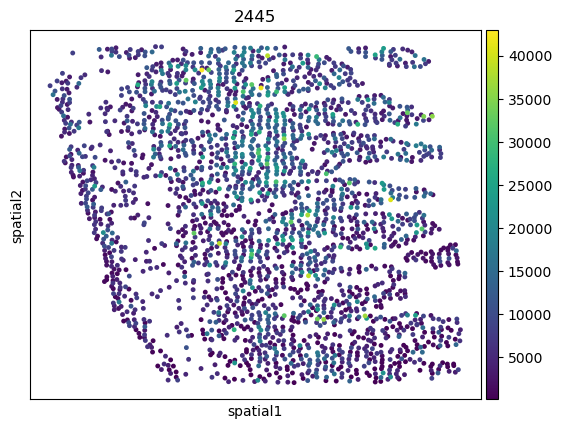

In [5]:
combined_adata.obs["umi_count"] = combined_adata.X.sum(axis = 1)
sc.pl.embedding(combined_adata, basis = "spatial", color = "umi_count", title = combined_adata.shape)

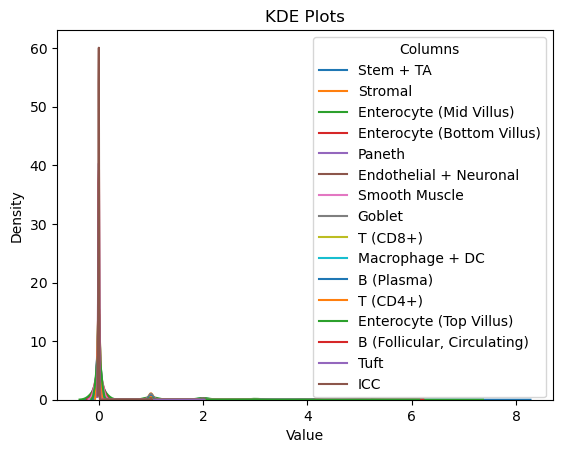

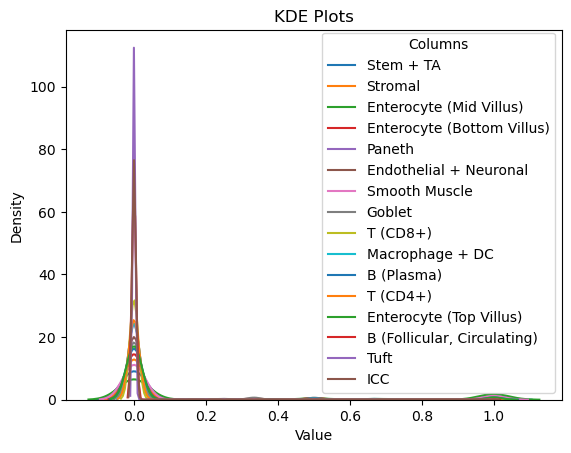

In [6]:
dt = combined_adata.obs
dt = dt[dt.columns[:-2]]
dt_ = dt.div(dt.sum(axis=1),axis=0)
diptest(dt)
diptest(dt_)

In [7]:
dt = dt.sort_index(axis=1)

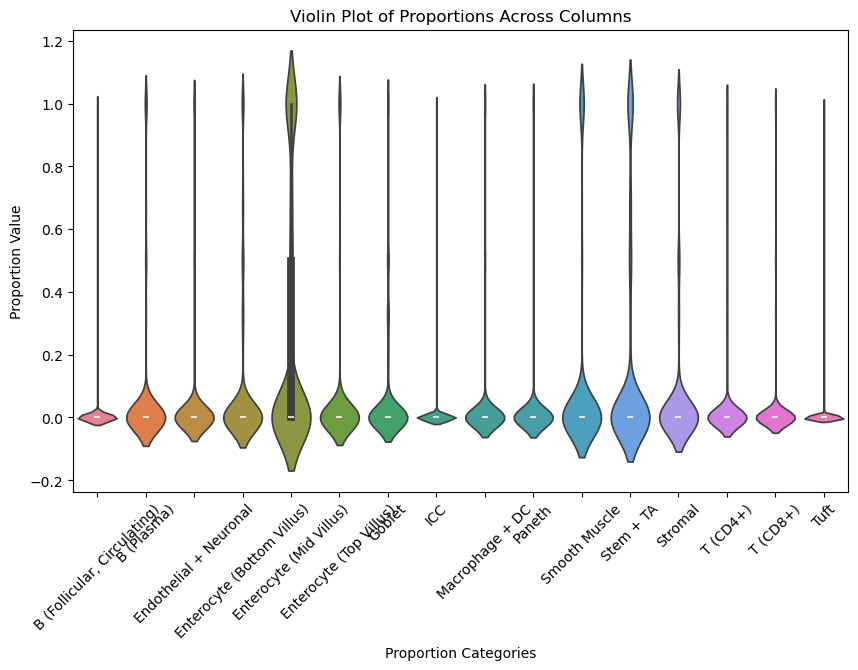

In [8]:
dt_ = dt_.sort_index(axis=1)

# Violin plot for more detailed distribution visualization
plt.figure(figsize=(10, 6))
sns.violinplot(data=dt_)
plt.title('Violin Plot of Proportions Across Columns')
plt.ylabel('Proportion Value')
plt.xlabel('Proportion Categories')
plt.xticks(rotation=45) #after creating the plot. Here's how you can adjust the code:
plt.show()

In [9]:
dt_

,"B (Follicular, Circulating)",B (Plasma),Endothelial + Neuronal,Enterocyte (Bottom Villus),Enterocyte (Mid Villus),Enterocyte (Top Villus),Goblet,ICC,Macrophage + DC,Paneth,Smooth Muscle,Stem + TA,Stromal,T (CD4+),T (CD8+),Tuft
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.5,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.5,0.0,0.0
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


(array([970.,   0.,   0., 698.,   0.,   0., 440.,   0.,   0.,   0., 195.,
          0.,   0.,  90.,   0.,   0.,   0.,  29.,   0.,   0.,  15.,   0.,
          0.,   8.]),
 array([1.        , 1.29166667, 1.58333333, 1.875     , 2.16666667,
        2.45833333, 2.75      , 3.04166667, 3.33333333, 3.625     ,
        3.91666667, 4.20833333, 4.5       , 4.79166667, 5.08333333,
        5.375     , 5.66666667, 5.95833333, 6.25      , 6.54166667,
        6.83333333, 7.125     , 7.41666667, 7.70833333, 8.        ]),
 <BarContainer object of 24 artists>)

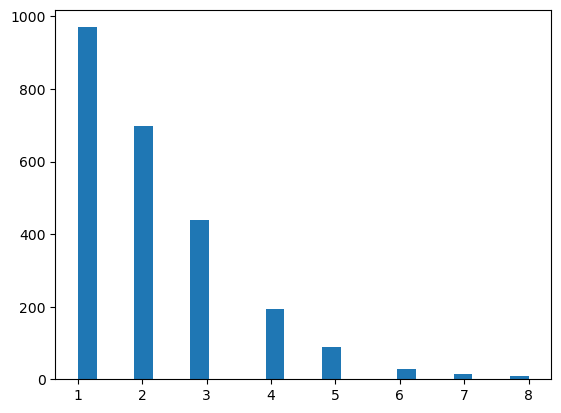

In [10]:
a = dt.sum(axis = 1)
plt.hist(a, bins='auto')

In [11]:
combined_adata.write_h5ad(binned_path)
no_of_cells = dt.sum(axis = 1)
no_of_cells.to_csv(path + "no_of_cells.csv")

res_path = "/data/Ajita/Spatial/Datasets/Spatial_Deconvolution/_Image_Binned_datasets/MERFISH_ileum/final_outputs_repo/gt.h5ad"

columns = combined_adata.obs.columns.tolist()[:-2]
loc = combined_adata.obsm["spatial"]#.to_numpy()
columns.sort()

ann_test = anndata.AnnData(dt_.to_numpy())
ann_test.obsm["Average_STAGATE_ReX"] = dt_.to_numpy()
ann_test.var_names = columns
ann_test.obsm["spatial"] = loc

print (ann_test)    
ann_test.write_h5ad(res_path) 

AnnData object with n_obs × n_vars = 2445 × 16
    obsm: 'Average_STAGATE_ReX', 'spatial'


In [12]:
combined_adata.var_names = st_adata.var_names
combined_adata.obs_names = [str(i) for i in range(len(combined_adata))]
print (combined_adata.obs_names, combined_adata.var_names)
combined_adata.write_h5ad(binned_path)

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
       ...
       '2435', '2436', '2437', '2438', '2439', '2440', '2441', '2442', '2443',
       '2444'],
      dtype='object', length=2445) Index(['gene', 'Acsl1', 'Acta2', 'Ada', 'Adgrd1', 'Adgrf5', 'Adra1a', 'Adra1b',
       'Adra1d', 'Adra2a',
       ...
       'Tm4sf4', 'Tnfrsf21', 'Tpsb2', 'Trdc', 'Trpm5', 'Tspan13', 'Txndc5',
       'Tymp', 'Vcan', 'Vim'],
      dtype='object', length=242)


### Spatial Pattern plots

In [17]:
dt_

,"B (Follicular, Circulating)",B (Plasma),Endothelial + Neuronal,Enterocyte (Bottom Villus),Enterocyte (Mid Villus),Enterocyte (Top Villus),Goblet,ICC,Macrophage + DC,Paneth,Smooth Muscle,Stem + TA,Stromal,T (CD4+),T (CD8+),Tuft
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.5,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.5,0.0,0.0
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


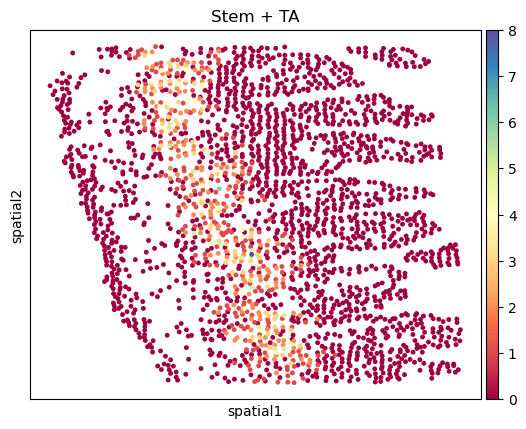

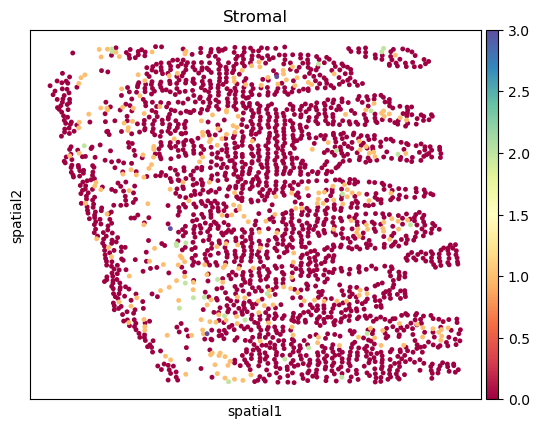

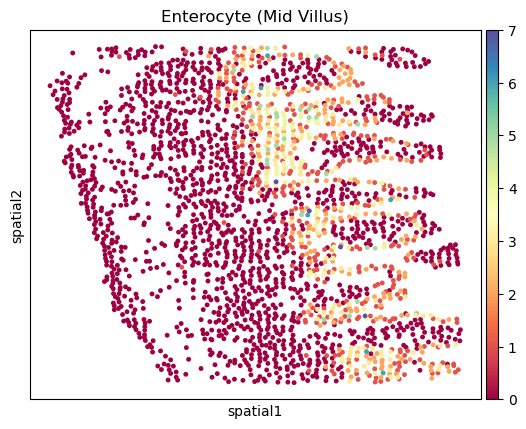

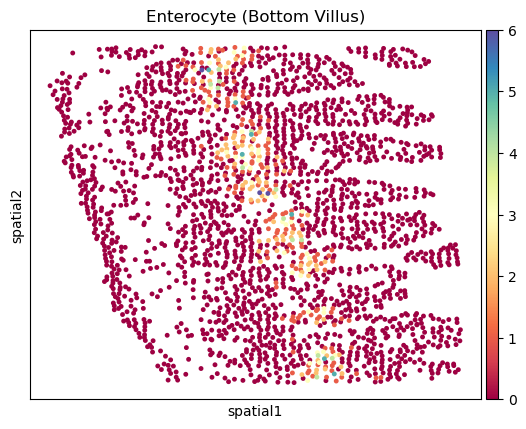

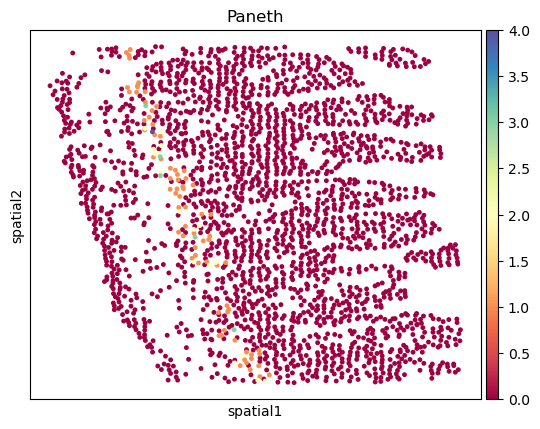

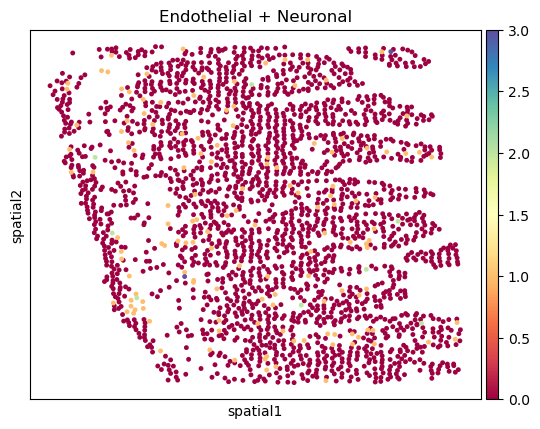

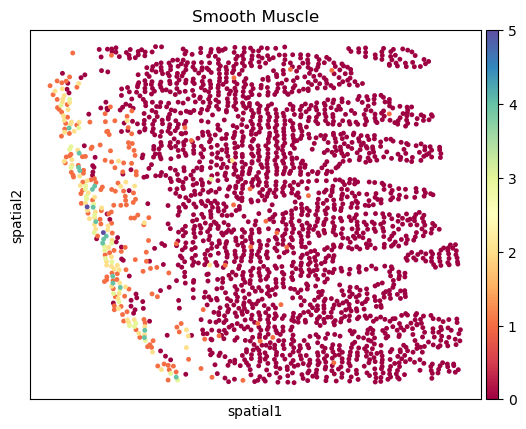

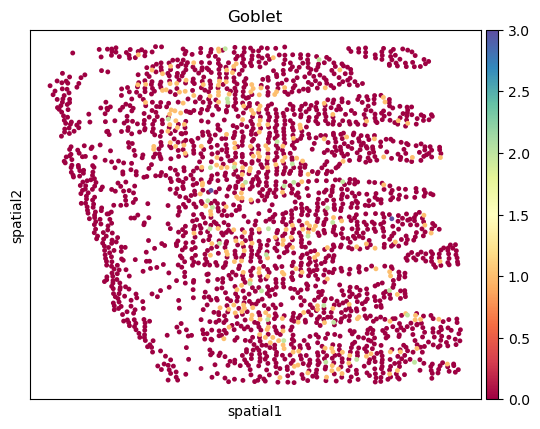

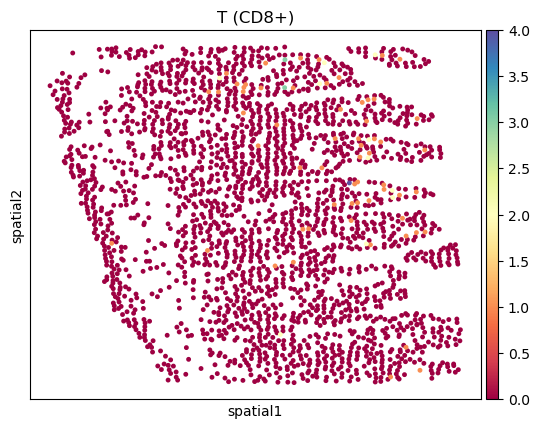

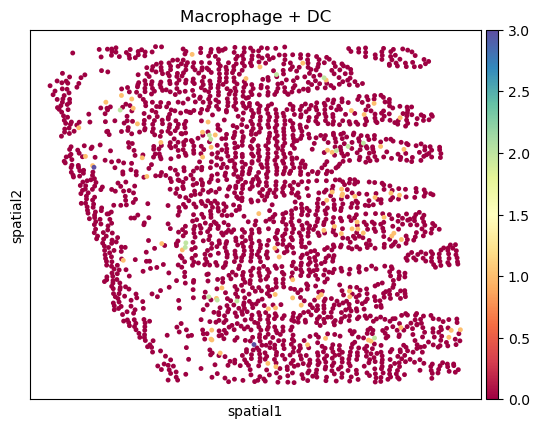

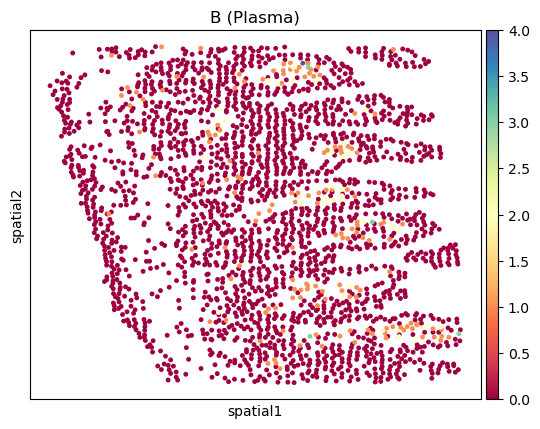

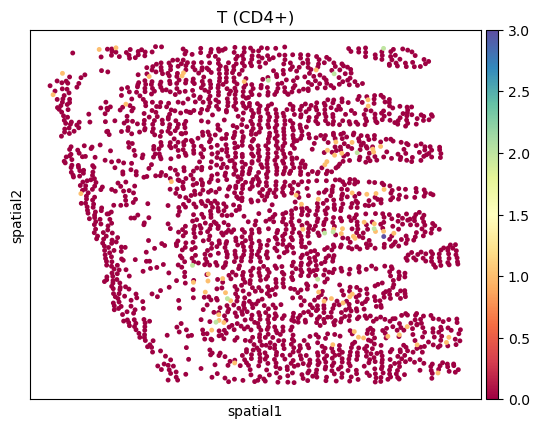

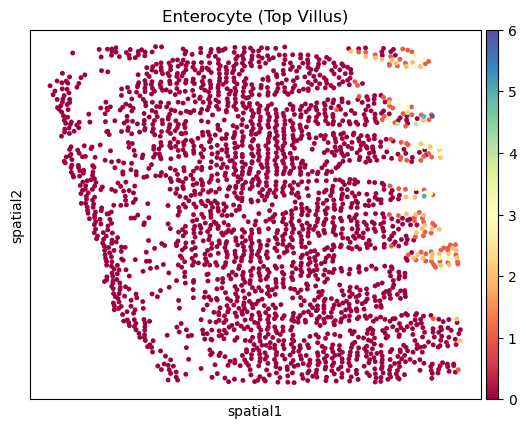

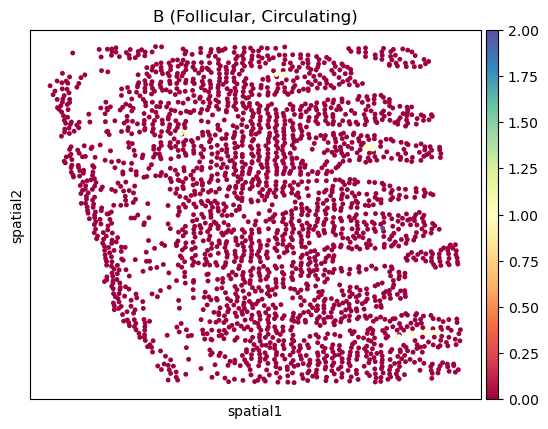

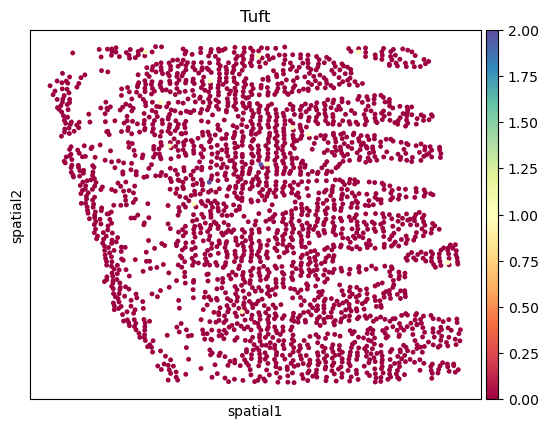

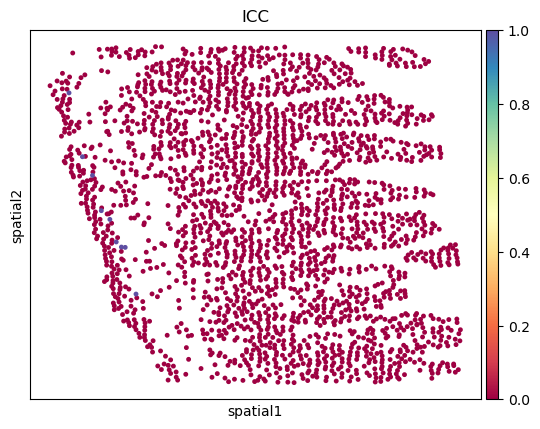

KeyboardInterrupt: 

In [15]:
for col in combined_adata.obs:
    sc.pl.embedding(combined_adata, basis = "spatial", color = col, cmap = "Spectral")